In [2]:
!pip install -q --upgrade torchvision torch

In [10]:
import pandas as pd
import numpy as np
import pickle
import os
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from torch.optim import Adam
from torchvision.models import convnext_base, ConvNeXt_Base_Weights
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import confusion_matrix, f1_score, accuracy_score, roc_auc_score, roc_curve
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
from datasets import load_dataset


In [16]:
import pandas as pd
import numpy as np
import pickle

from tqdm import tqdm
from datasets import load_dataset

def code_to_image(code: str, image_size: int = 32) -> np.ndarray:
    code_bytes = code.encode('utf-8', errors='ignore')
    total_pixels = image_size * image_size
    if len(code_bytes) >= total_pixels:
        pixels = list(code_bytes[:total_pixels])
    else:
        pixels = list(code_bytes) + [0] * (total_pixels - len(code_bytes))
    return np.array(pixels, dtype=np.uint8).reshape(image_size, image_size)


def load_and_convert_dataset(output_path: str = 'code_images.parquet') -> pd.DataFrame:
    print("Loading HuggingFace dataset...")
    dataset = load_dataset("DaniilOr/CoDET-M4", split='train')

    print(f"Dataset loaded: {len(dataset)} samples")
    dataset = dataset.filter(lambda x: x['split'] == 'val')
    python_samples = dataset.filter(lambda x: x['language'] == 'python')
    print(f"Python samples: {len(python_samples)}")

    data_records = []
    print("Converting code to images...")
    for sample in tqdm(python_samples):
        if 'code' in sample and sample['code']:
            image_array = code_to_image(sample['code'])
            image_bytes = pickle.dumps(image_array)

            record = {
                'code_text': sample['code'],
                'code_image': image_bytes,
                'model': sample.get('model'),
                'target': sample.get('target'),
                'language': sample.get('language'),
            }

            for key in sample.keys():
                if key not in record and key not in ['code']:
                    record[key] = sample.get(key)

            data_records.append(record)

    print(f"Converted {len(data_records)} code samples to images")

    df = pd.DataFrame(data_records)
    print(f"DataFrame shape: {df.shape}")
    print(f"DataFrame columns: {df.columns.tolist()}")
    df.dropna(subset=['model'], inplace=True)
    print(f"DataFrame shape after dropping 'model' column with NaN values: {df.shape}")

    df.to_parquet(output_path, index=False)
    print(f"Saved to {output_path}")

    return df

In [17]:
df = load_and_convert_dataset()
print(df.info())
if len(df) > 0:
    image = pickle.loads(df['code_image'].iloc[0])
    print(f"First row code image shape: {image.shape}")

Loading HuggingFace dataset...
Dataset loaded: 500552 samples
Python samples: 17685
Converting code to images...


100%|██████████| 17685/17685 [00:05<00:00, 3187.14it/s]


Converted 17685 code samples to images
DataFrame shape: (17685, 10)
DataFrame columns: ['code_text', 'code_image', 'model', 'target', 'language', 'split', 'source', 'features', 'cleaned_code', '__index_level_0__']
DataFrame shape after dropping 'model' column with NaN values: (16947, 10)
Saved to code_images.parquet
<class 'pandas.core.frame.DataFrame'>
Index: 16947 entries, 0 to 17684
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   code_text          16947 non-null  object
 1   code_image         16947 non-null  object
 2   model              16947 non-null  object
 3   target             16947 non-null  object
 4   language           16947 non-null  object
 5   split              16947 non-null  object
 6   source             16947 non-null  object
 7   features           16947 non-null  object
 8   cleaned_code       16947 non-null  object
 9   __index_level_0__  16947 non-null  int64 
dtypes: int64(

In [ ]:
X, y, le, df = load_dataset()

num_classes = len(np.unique(y))
print(f"Number of classes: {num_classes}")
print(f"Target column: {CONFIG['target_column']}")
print(f"Classes: {le.classes_}")

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=CONFIG['test_size'], random_state=CONFIG['seed'], stratify=y
)

train_dataset = TensorDataset(torch.from_numpy(X_train), torch.from_numpy(y_train))
test_dataset = TensorDataset(torch.from_numpy(X_test), torch.from_numpy(y_test))

train_loader = DataLoader(train_dataset, batch_size=CONFIG['batch_size'], shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=CONFIG['batch_size'], shuffle=False)

model = create_model(num_classes).to(CONFIG['device'])
model_path = f"results/model_{CONFIG['target_column']}.pth"

# Check if a pre-trained model exists
if os.path.exists(model_path):
    print(f"Loading pre-trained model from {model_path}")
    model.load_state_dict(torch.load(model_path, map_location=CONFIG['device']))
else:
    print("No pre-trained model found, training from scratch.")
    criterion = nn.CrossEntropyLoss()
    optimizer = Adam(model.parameters(), lr=CONFIG['learning_rate'])

    print(f"\nTraining on {CONFIG['device']}...")
    for epoch in range(CONFIG['epochs']):
        loss = train_epoch(model, train_loader, optimizer, criterion, CONFIG['device'])
        print(f"Epoch {epoch+1}/{CONFIG['epochs']}, Loss: {loss:.4f}")

    # Save the trained model
    os.makedirs('results', exist_ok=True) # Ensure results directory exists before saving
    torch.save(model.state_dict(), model_path)
    print(f"Model saved to {model_path}")

print("\nEvaluating...")
preds, labels, probs = evaluate(model, test_loader, CONFIG['device'])

accuracy = accuracy_score(labels, preds)
f1 = f1_score(labels, preds, average='weighted', zero_division=0)
cm = confusion_matrix(labels, preds)

if num_classes == 2:
    auc = roc_auc_score(labels, probs[:, 1])
else:
    auc = roc_auc_score(labels, probs, multi_class='ovr')

results_df = pd.DataFrame({
    'metric': ['accuracy', 'f1_score', 'auc'],
    'value': [accuracy, f1, auc]
})

os.makedirs('results', exist_ok=True)
results_df.to_csv('results/metrics.csv', index=False)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title(f'Confusion Matrix - {CONFIG["target_column"]}')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.savefig('results/confusion_matrix.png', dpi=150)

print(f"\nResults:")
print(f"  Accuracy: {accuracy:.4f}")
print(f"  F1 Score: {f1:.4f}")
print(f"  AUC: {auc:.4f}")
print(f"\nConfusion Matrix:\n{cm}")
print(f"\nResults saved to results/")

In [ ]:
X, y, le, df = load_dataset()

num_classes = len(np.unique(y))
print(f"Number of classes: {num_classes}")
print(f"Target column: {CONFIG['target_column']}")
print(f"Classes: {le.classes_}")

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=CONFIG['test_size'], random_state=CONFIG['seed'], stratify=y
)

train_dataset = TensorDataset(torch.from_numpy(X_train), torch.from_numpy(y_train))
test_dataset = TensorDataset(torch.from_numpy(X_test), torch.from_numpy(y_test))

train_loader = DataLoader(train_dataset, batch_size=CONFIG['batch_size'], shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=CONFIG['batch_size'], shuffle=False)

model = create_model(num_classes).to(CONFIG['device'])
criterion = nn.CrossEntropyLoss()
optimizer = Adam(model.parameters(), lr=CONFIG['learning_rate'])

print(f"\nTraining on {CONFIG['device']}...")
for epoch in range(CONFIG['epochs']):
    loss = train_epoch(model, train_loader, optimizer, criterion, CONFIG['device'])
    print(f"Epoch {epoch+1}/{CONFIG['epochs']}, Loss: {loss:.4f}")

print("\nEvaluating...")
preds, labels, probs = evaluate(model, test_loader, CONFIG['device'])

accuracy = accuracy_score(labels, preds)
f1 = f1_score(labels, preds, average='weighted', zero_division=0)
cm = confusion_matrix(labels, preds)

if num_classes == 2:
    auc = roc_auc_score(labels, probs[:, 1])
else:
    auc = roc_auc_score(labels, probs, multi_class='ovr')

results_df = pd.DataFrame({
    'metric': ['accuracy', 'f1_score', 'auc'],
    'value': [accuracy, f1, auc]
})

os.makedirs('results', exist_ok=True)
results_df.to_csv('results/metrics.csv', index=False)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title(f'Confusion Matrix - {CONFIG["target_column"]}')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.savefig('results/confusion_matrix.png', dpi=150)

print(f"\nResults:")
print(f"  Accuracy: {accuracy:.4f}")
print(f"  F1 Score: {f1:.4f}")
print(f"  AUC: {auc:.4f}")
print(f"\nConfusion Matrix:\n{cm}")
print(f"\nResults saved to results/")

Loading dataset...
Loaded 16947 samples


Decoding images: 100%|██████████| 16947/16947 [00:00<00:00, 173594.49it/s]


Number of classes: 2
Target column: target
Classes: ['ai' 'human']
Downloading: "https://download.pytorch.org/models/convnext_base-6075fbad.pth" to /root/.cache/torch/hub/checkpoints/convnext_base-6075fbad.pth


100%|██████████| 338M/338M [00:05<00:00, 69.6MB/s]



Training on cuda...


Epoch 1/10, Loss: 0.5011


Epoch 2/10, Loss: 0.3432


Epoch 3/10, Loss: 0.2463


Training:  19%|█▉        | 80/424 [00:06<00:25, 13.48it/s]

) missing from font(s) DejaVu Sans.
  plt.tight_layout(rect=[0, 0.03, 1, 0.95])
) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


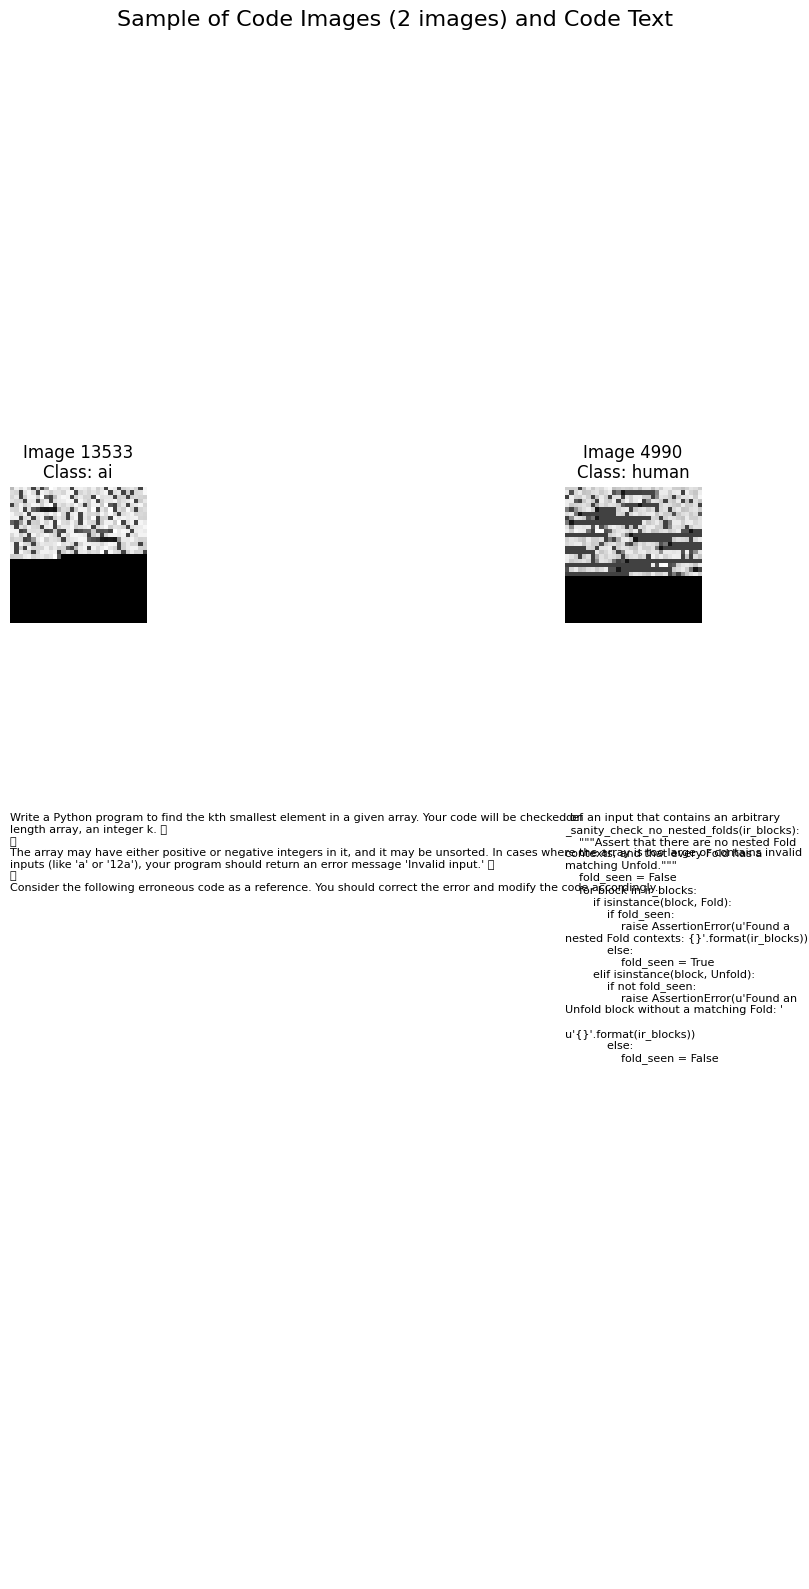

In [ ]:
import matplotlib.pyplot as plt
import random

# Validate and use the configurable number of samples
num_samples = CONFIG['num_sample_images']
if not (2 <= num_samples <= 10):
    print(f"Warning: 'num_sample_images' in CONFIG is outside the valid range [2, 10]. Using 5 samples instead.")
    num_samples = 5

# Select random rows to visualize
sample_df = df.sample(n=num_samples, random_state=CONFIG['seed'])

# Adjust figure size based on the number of samples
fig_width = num_samples * 4  # Increased width multiplier for larger images
fig_height = 16 # Increased height for larger images and text
plt.figure(figsize=(fig_width, fig_height))

for i, (idx, row) in enumerate(sample_df.iterrows()):
    image_bytes = row['code_image']
    image_array = pickle.loads(image_bytes)
    code_text = row['code_text']

    ax = plt.subplot(2, num_samples, i + 1) # First row for images
    ax.imshow(image_array, cmap='gray')
    ax.set_title(f"Image {idx}\nClass: {row['target']}")
    ax.axis('off')

    # Display code text below the image
    ax_text = plt.subplot(2, num_samples, i + num_samples + 1) # Second row for text
    ax_text.text(0, 1, code_text, fontsize=8, verticalalignment='top', horizontalalignment='left', wrap=True)
    ax_text.axis('off')

plt.suptitle(f'Sample of Code Images ({num_samples} images) and Code Text', y=1.02, fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

The above plot shows 5 randomly selected code images after being converted to 32x32 grayscale NumPy arrays. Each image is accompanied by its corresponding target class ('ai' or 'human').